In [1]:
#NLP + Deep Learning (Generative AI)

#Word Embedding

In [2]:
#!pip install tensorflow

In [3]:
#1.IMPORTING LIBRARIES AND LOADING DATASET

import pandas as pd
# import → Keyword used to bring a library into the notebook
# pandas → Library for handling tabular data (DataFrames)
# as → Keyword used to give the library a short alias
# pd → Alias used to refer to pandas in the code

import numpy as np
# import → Keyword used to bring a library into the notebook
# numpy → Library for numerical and array operations
# as → Keyword used to give the library a short alias
# np → Alias used to refer to numpy in the code

import tensorflow as tf
# import → Keyword used to bring a library into the notebook
# tensorflow → Deep learning framework
# as → Keyword used to give the library a short alias
# tf → Alias used to refer to tensorflow in the code

from tensorflow import keras
# from → Keyword to import a specific part of a library
# tensorflow → The parent library
# import → Keyword used to bring in the specified item
# keras → TensorFlow's high-level API for building neural networks

from tensorflow.keras.layers import Embedding, LSTM, Dense
# from → Keyword to import from a specific module path
# tensorflow.keras.layers → Module containing neural network layer types
# import → Keyword used to bring in the specified items
# Embedding → Layer that converts words into numeric vectors
# LSTM → Layer that remembers sequence/order information
# Dense → Layer that fully connects neurons to the next layer

from tensorflow.keras.models import Sequential
# from → Keyword to import from a specific module path
# tensorflow.keras.models → Module containing model-building classes
# import → Keyword used to bring in the specified item
# Sequential → Class used to build a model as a linear stack of layers

train = pd.read_csv("engtamilTrain.csv")
# train → Variable name storing the result
# = → Assignment operator
# pd → Alias for pandas
# .read_csv → Function that reads a CSV file
# ("engtamilTrain.csv") → Argument specifying the file name to read

train = train.drop(["Unnamed: 0"], axis=1)
# train → Variable being reassigned
# = → Assignment operator
# train → Original DataFrame
# .drop → Function that removes rows or columns
# (["Unnamed: 0"] → Argument listing the column name to remove
# axis=1) → Argument specifying column-wise removal (1 = columns)

english_sentences = train["en"]
# english_sentences → Variable name storing the result
# = → Assignment operator
# train → The DataFrame
# ["en"] → Indexing operator selecting the column named "en"

tamil_sentence = train['ta']
# tamil_sentence → Variable name storing the result
# = → Assignment operator
# train → The DataFrame
# ['ta'] → Indexing operator selecting the column named "ta"

english_sentences = english_sentences.head(1000)
# english_sentences → Variable being reassigned
# = → Assignment operator
# english_sentences → Original Series
# .head → Function that returns the first rows
# (1000) → Argument specifying how many rows to return

tamil_sentences = tamil_sentence.head(1000)
# tamil_sentences → Variable name storing the result
# = → Assignment operator
# tamil_sentence → Original Series
# .head → Function that returns the first rows
# (1000) → Argument specifying how many rows to return

# This cell imports the required libraries and loads the first 1000 English-Tamil sentence pairs for translation model training.

In [4]:
#!pip install gensim

In [5]:
#2.IMPORTING WORD2VEC, PCA, AND PYPLOT

from gensim.models import Word2Vec
# from → Keyword to import from a specific module path
# gensim.models → Module containing word-embedding model classes
# import → Keyword used to bring in the specified item
# Word2Vec → Class used to train word embedding models

from sklearn.decomposition import PCA
# from → Keyword to import from a specific module path
# sklearn.decomposition → Module containing dimensionality reduction tools
# import → Keyword used to bring in the specified item
# PCA → Class used to reduce high-dimensional data into fewer dimensions

from matplotlib import pyplot
# from → Keyword to import from a specific module path
# matplotlib → Library used for creating plots and visualizations
# import → Keyword used to bring in the specified item
# pyplot → Module used to create charts and graphs

# This cell imports Word2Vec for word embeddings, PCA for dimensionality reduction, and pyplot for visualizing the embeddings.

In [6]:
#3.DEFINING A FUNCTION TO TOKENIZE SENTENCES

def sentToken(sentence):
# def → Keyword used to define a function
# sentToken → Name given to the function
# (sentence) → Parameter representing the input passed to the function
# : → Marks the start of the function body

    dataset = sentence
    # dataset → Variable name storing the result
    # = → Assignment operator
    # sentence → The input parameter passed to the function

    sentences = [sentence.split() for sentence in dataset]
    # sentences → Variable name storing the result
    # = → Assignment operator
    # [ ] → List comprehension brackets, building a new list
    # sentence.split() → Splits each sentence into a list of words (default: by spaces)
    # for → Keyword starting the loop inside the list comprehension
    # sentence → Loop variable representing each item
    # in → Keyword linking the loop variable to the iterable
    # dataset → The collection being looped over

    print(sentences)
    # print → Built-in function that displays output
    # (sentences) → Argument specifying what to display

    return sentences
    # return → Keyword that sends a value back from the function
    # sentences → The value being returned

# This function takes a dataset of sentences, splits each sentence into individual words, prints the result, and returns the tokenized sentences.

In [7]:
#4.TOKENIZING THE ENGLISH SENTENCES

engSentence = sentToken(english_sentences)
# engSentence → Variable name storing the result
# = → Assignment operator
# sentToken → The function defined earlier to tokenize sentences
# (english_sentences) → Argument passing the English sentences data into the function

# This cell calls the sentToken function on the English sentences to split them into lists of words.

[['MMA', 'vice', 'president', 'Qazi', 'Hussain', 'Ahmad', 'declared', 'last', 'month:', "'We", 'are', 'not', 'extremists.'], ['Information', 'has', 'surfaced', 'in', 'recent', 'years', 'suggesting', 'that', 'Julius', 'Rosenberg', 'was', 'involved', 'in', 'passing', 'some', 'form', 'of', 'intelligence', 'to', 'Soviet', 'officials', 'during', 'the', 'Second', 'World', 'War.'], ['And', 'Azor', 'begat', 'Sadoc;', 'and', 'Sadoc', 'begat', 'Achim;', 'and', 'Achim', 'begat', 'Eliud;'], ['She', 'says', 'she', 'knows', 'what', 'is', 'going', 'on,', 'but', 'can', 'do', 'nothing', 'about', 'it.'], ['And', 'be', 'it', 'indeed', 'that', 'I', 'have', 'erred,', 'my', 'error', 'remains', 'with', 'myself.'], ['Finally,', 'the', 'columnist', 'fails', 'to', 'tell', 'us', 'who', 'among', 'the', 'political', 'leaders', 'of', 'the', 'bourgeoisie,', 'past', 'and', 'present,', 'he', 'counts', 'among', 'the', 'paragons', 'of', 'morality.'], ['These', 'include', 'the', 'British', 'Tamil', 'Forum,', 'La', 'Maiso

In [8]:
#5.TOKENIZING THE TAMIL SENTENCES

tamSentence = sentToken(tamil_sentences)
# tamSentence → Variable name storing the result
# = → Assignment operator
# sentToken → The function defined earlier to tokenize sentences
# (tamil_sentences) → Argument passing the Tamil sentences data into the function

# This cell calls the sentToken function on the Tamil sentences to split them into lists of words.

[['MMA', 'கட்சியின்', 'துணைத்தலைவர்', 'க்வாஸி', 'ஹுசேன்', 'அகமத்', 'சென்ற', 'மாதம்', 'பின்வருமாறு', 'அறிவித்தார்:', '``நாங்கள்', 'தீவிரவாதிகள்', 'அல்ல.'], ['சமீபகாலத்தில்', 'சில', 'தகவல்கள்', 'யூலியஸ்', 'ரோசன்பேர்க்', 'ஒரு', 'வித', 'உளவுச்செய்தியை', 'சோவியத்', 'அதிகாரிகளுக்கு', 'இரண்டாம்', 'உலகப்போரின்போது', 'அனுப்பியதில்', 'சம்பந்தப்பட்டு', 'இருந்ததாக', 'வெளிவந்துள்ளன.'], ['ஆசோர்', 'சாதோக்கைப்', 'பெற்றான்;', 'சாதோக்கு', 'ஆகீமைப்', 'பெற்றான்;', 'ஆகீம்', 'எலியூதைப்', 'பெற்றான்;'], ['என்ன', 'நடக்கிறது', 'என்பது', 'தமக்கு', 'தெரியும்', 'என்றும்', 'ஆனால்,', 'தம்மால்', 'எதுவும்', 'செய்யமுடியாது', 'என்றும்', 'கடிதம்', 'எழுதியிருந்தார்.'], ['நான்', 'தப்பிநடந்தது', 'மெய்யானாலும்,', 'என்', 'தப்பிதம்', 'என்னோடேதான்', 'இருக்கிறது'], ['டால்ரிம்பிளினுடைய', 'அறிவுஜீவித்', 'தொடுவானத்திற்கு', 'அப்பால்', 'எவ்வளவோ', 'தொலைவில்', 'இருந்தன'], ['இந்த', 'அமைப்புக்களில்', 'British', 'Tamil', 'Forum,', 'La', 'Maison', 'du', 'Tamil', 'Eelam', '(France),', 'the', 'Canadian', 'Tamil', 'Congress,', 'Swiss',

In [9]:
#Pre-Trained Models Links to Reference

#https://radimrehurek.com/gensim_3.8.3/models/word2vec.html
#https://radimrehurek.com/gensim/models/word2vec.html

In [10]:
#6.DEFINING A FUNCTION TO TRAIN AND VISUALIZE WORD2VEC MODEL

def ownWordModel(langsentence, modelname):
# def → Keyword used to define a function
# ownWordModel → Name given to the function
# (langsentence, modelname) → Parameters: input sentences and the name to save the model as
# : → Marks the start of the function body

    from gensim.models import Word2Vec
    # from → Keyword to import from a specific module path
    # gensim.models → Module containing word-embedding model classes
    # import → Keyword used to bring in the specified item
    # Word2Vec → Class used to train word embedding models

    from sklearn.decomposition import PCA
    # from → Keyword to import from a specific module path
    # sklearn.decomposition → Module containing dimensionality reduction tools
    # import → Keyword used to bring in the specified item
    # PCA → Class used to reduce high-dimensional data into fewer dimensions

    import matplotlib.pyplot as plt
    # import → Keyword used to bring a library into the notebook
    # matplotlib.pyplot → Module used to create charts and graphs
    # as → Keyword used to give the module a short alias
    # plt → Alias used to refer to pyplot in the code

    model = Word2Vec(langsentence, min_count=1)
    # model → Variable name storing the result
    # = → Assignment operator
    # Word2Vec → Class used to train the word embedding model
    # (langsentence → Argument passing the tokenized sentences
    # min_count=1) → Argument setting minimum word frequency to include (1 = include all words)

    print(model)
    # print → Built-in function that displays output
    # (model) → Argument specifying what to display

    model.save(modelname)
    # model → The trained Word2Vec model
    # .save → Function that saves the model to disk
    # (modelname) → Argument specifying the file name to save as

    X = model.wv.vectors
    # X → Variable name storing the result
    # = → Assignment operator
    # model → The trained model
    # .wv → Attribute holding the word vectors
    # .vectors → Attribute returning all word vectors as an array

    pca = PCA(n_components=2)
    # pca → Variable name storing the result
    # = → Assignment operator
    # PCA → Class used for dimensionality reduction
    # (n_components=2) → Argument specifying output should have 2 dimensions

    result = pca.fit_transform(X)
    # result → Variable name storing the result
    # = → Assignment operator
    # pca → The PCA object
    # .fit_transform → Function that fits PCA and transforms the data
    # (X) → Argument passing the word vectors to reduce

    plt.scatter(result[:, 0], result[:, 1])
    # plt → Alias for pyplot
    # .scatter → Function that creates a scatter plot
    # (result[:, 0] → Argument passing all rows of the first column (x-axis values)
    # result[:, 1]) → Argument passing all rows of the second column (y-axis values)

    words = list(model.wv.index_to_key)
    # words → Variable name storing the result
    # = → Assignment operator
    # list → Built-in function that converts input into a list
    # (model.wv.index_to_key) → Argument passing all vocabulary words from the model

    for i, word in enumerate(words):
    # for → Keyword starting a loop
    # i, word → Loop variables: index number and the word itself
    # in → Keyword linking loop variables to the iterable
    # enumerate → Built-in function that pairs each item with its index number
    # (words) → Argument passing the list of vocabulary words
    # : → Marks the start of the loop body

        plt.annotate(word, xy=(result[i, 0], result[i, 1]))
        # plt → Alias for pyplot
        # .annotate → Function that adds a text label to the plot
        # (word → Argument specifying the label text
        # xy=(result[i, 0] → Argument setting the x-coordinate for the label
        # result[i, 1])) → Argument setting the y-coordinate for the label

    plt.show()
    # plt → Alias for pyplot
    # .show → Function that displays the plot

# This function trains a Word2Vec model on the given sentences, saves it, reduces the word vectors to 2D using PCA, 
# and plots each word on a scatter chart with labels.

Word2Vec<vocab=7300, vector_size=100, alpha=0.025>


C:\Users\bkann\anaconda3\envs\aiml\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128 (\x80) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\bkann\anaconda3\envs\aiml\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 147 (\x93) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\bkann\anaconda3\envs\aiml\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 130 (\x82) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\bkann\anaconda3\envs\aiml\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 159 (\x9f) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


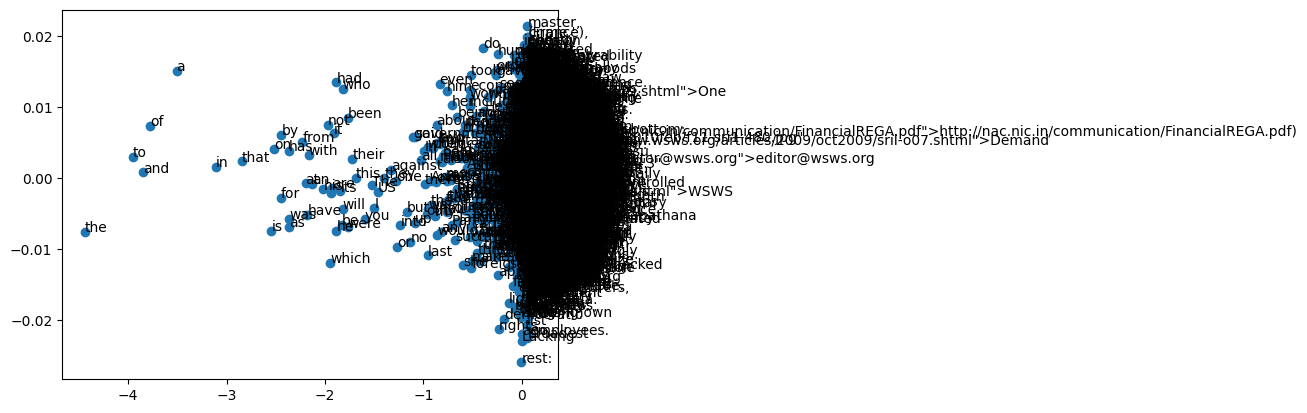

In [11]:
#7.TRAINING AND SAVING THE ENGLISH WORD2VEC MODEL

ownWordModel(engSentence, "engmodel.bin")
# ownWordModel → The function defined earlier to train and visualize a Word2Vec model
# (engSentence → Argument passing the tokenized English sentences
# "engmodel.bin") → Argument specifying the file name to save the trained model as

# This cell calls ownWordModel on the tokenized English sentences to train a Word2Vec model, save it as "engmodel.bin", 
# and display the word embedding plot.

Word2Vec<vocab=9882, vector_size=100, alpha=0.025>


C:\Users\bkann\anaconda3\envs\aiml\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2962 (\N{TAMIL LETTER O}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\bkann\anaconda3\envs\aiml\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Tamil natively.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\bkann\anaconda3\envs\aiml\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2992 (\N{TAMIL LETTER RA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\bkann\anaconda3\envs\aiml\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3009 (\N{TAMIL VOWEL SIGN U}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\bkann\anaconda3\envs\aiml\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2990 (\N{TAMIL LETTER MA}) missing from font(s) DejaVu Sans.
  fig.canvas.print

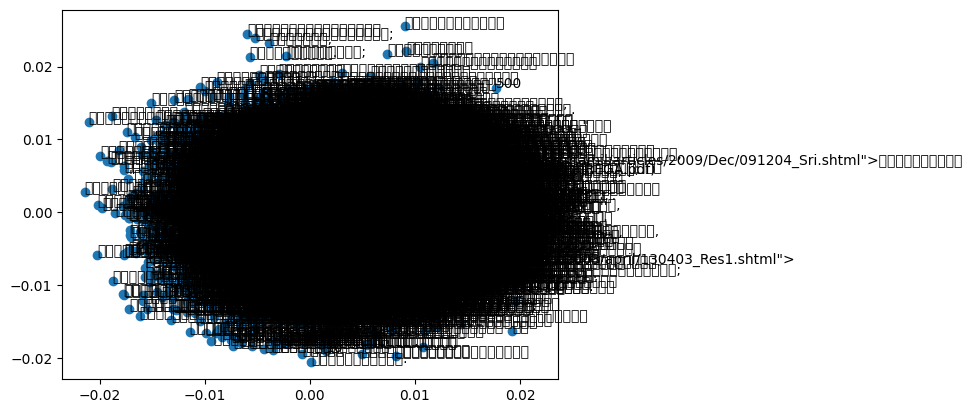

In [12]:
#8.TRAINING AND SAVING THE TAMIL WORD2VEC MODEL

ownWordModel(tamSentence, "tammodel.bin")
# ownWordModel → The function defined earlier to train and visualize a Word2Vec model
# (tamSentence → Argument passing the tokenized Tamil sentences
# "tammodel.bin") → Argument specifying the file name to save the trained model as

# This cell calls ownWordModel on the tokenized Tamil sentences to train a Word2Vec model, save it as "tammodel.bin", 
# and display the word embedding plot.